# Measurement x=15, y=0, z=0

### Imports

In [41]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import plot_timeseries
from python_utils.data_processing import print_loaded_data_example

### General Args

In [42]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1
B_z = -1

### Load Data

In [43]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [44]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    fld_timeseries = fld_data['timeseries']
    fld_labels = fld_data['labels']
print_loaded_data_example(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
    gradF_timeseries = gradF_data['timeseries']
    gradF_labels = gradF_data['labels']
print_loaded_data_example(gradF_data)

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
[[-1.        -1.         0.       ]
 [-0.9872207 -1.         0.       ]
 [-0.9667644 -1.         0.       ]
 [-0.9389384 -1.         0.       ]
 [-0.9042407 -1.         0.       ]]

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 5
Labels:
['y', 'z', 'dfdx', 'dfdy', 'dfdz']
[[-1.         -1.          0.2027423 ]
 [-0.9872207  -1.          0.1220912 ]
 [-0.9667644  -1.          0.08098662]
 [-0.9389384  -1.          0.2557448 ]
 [-0.9042407  -1.          1.052832  ]]


### Get Existing x and y Coordinates

In [45]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_center = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Plot $v_x$

 x = streamwise

In [46]:
v_x_center = extract_timeseries(
    data=fld_data,
    column_labels='vx',
    y_coord=y_coord,
    z_coord=z_coord,
    )

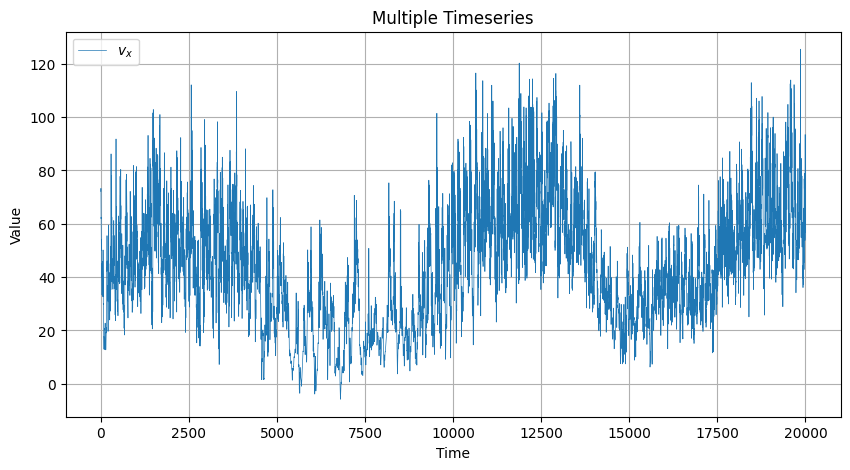

In [47]:
plot_timeseries(
    v_x_center,
    labels=["$v_{x}$"],
    linewidth=0.5,
    )

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

### Voltage (Potential Difference) $\Phi$

##### Real Voltage

This one can not be measured directly by the potential probe.

In [48]:
part_phi_y = extract_timeseries(
    data=gradF_data,
    column_labels="dfdy",
    y_coord=y_coord,
    z_coord=z_coord,
    )

##### Approx Voltage with Symmetric Difference Quotient

In [49]:
"""Get indices for symmetric difference quotient points.

y_1_y = (y_1_y, y_1_z)
y_2_y = (y_2_y, y_2_z)
y_1_y < y_coord < y_2_y
y_1_z = z_coord = y_2_z

"""

delta_l = 0.1  # y, z domain = [-1, 1]

print(f"Center: y = {fld_timeseries[0][i_center][0]}, z = {fld_timeseries[0][i_center][1]}")


# Find y_1
y_1_y_desired = y_coord - delta_l / 2
y_1_z_desired = z_coord

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_1_y = y_1_y_desired
# y_1_z = y_1_z_desired
if Ha == 300:
    y_1_y = -0.01842125
    y_1_z = -0.01842125
elif Ha == 1000:
    y_1_y = -0.03460649
    y_1_z = 0

i_y_1 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_1_y,
    z_coord=y_1_z,
    )

print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: delta_y^y_1 = {y_1_y - y_coord}, ", end='')
print(f"delta_z^y_1 = {y_1_z - z_coord}, delta_i^y_1 = {i_y_1 - i_center}")


# Find y_2
y_2_y_desired = y_coord + delta_l / 2
y_2_z_desired = z_coord

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_2_y = y_2_y_desired
# y_2_z = y_2_z_desired
if Ha == 300:
    y_2_y = 0.01842125
    y_2_z = -0.01842125
elif Ha == 1000:
    y_2_y = 0.03460649
    y_2_z = 0

i_y_2 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_2_y,
    z_coord=y_2_z,
    )

print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: delta_y^y_2 = {y_2_y - y_coord}, ", end='')
print(f"delta_z^y_2 = {y_2_z - z_coord}, delta_i^y_2 = {i_y_2 - i_center}")


# Compare y_1 and y_2
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_y_2 - i_y_1}")

Center: y = -0.01842125, z = -0.01842125
y_1 Coordinates: y = -0.01842125, z = -0.01842125
Difference to center: delta_y^y_1 = 0.0, delta_z^y_1 = 0.0, delta_i^y_1 = 0
y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i^y_2 = 1
Difference between y_1 to y_2: delta_y = 0.0368425, delta_z = 0.0, delta_i = 1


In [50]:
"""Approximate Voltage with Symmetric Difference Coefficient
"""

phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )

delta_phi_y = phi_y_2 - phi_y_1
approx_part_phi_y = delta_phi_y / delta_y

##### Compare Real with Approximate Voltage $\Phi$

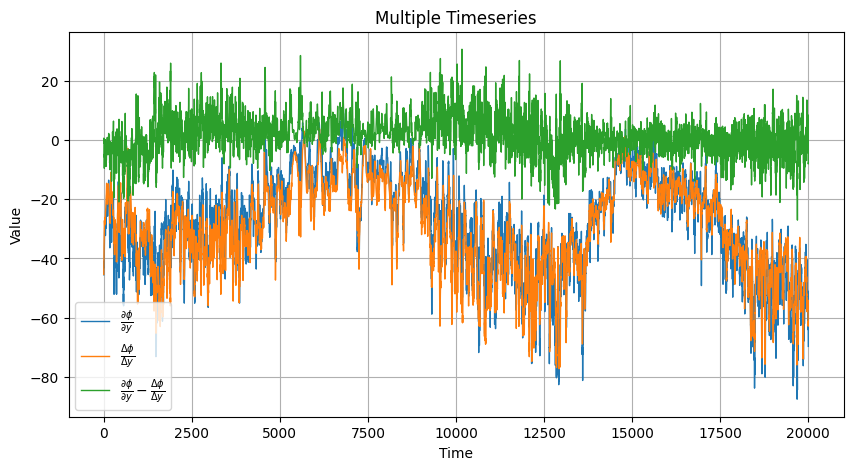

In [51]:
plot_timeseries(
    data_list=[
        part_phi_y,
        approx_part_phi_y,
        part_phi_y - approx_part_phi_y,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{y}}$",
        "$\\frac{\\Delta{\\phi}}{\\Delta{y}}$",
        "$\\frac{\\partial{\\phi}}{\\partial{y}} - \\frac{\\Delta{\\phi}}{\\Delta{y}}$"
        ],
    linewidth=1,
    )

### Plot $v_x^{pdm}$

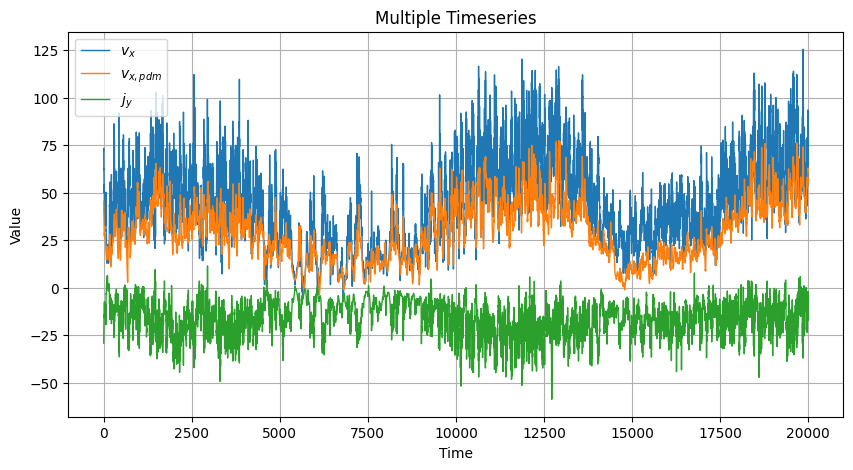

In [52]:
j_y_center = extract_timeseries(
    data=fld_data,
    column_labels='jy',
    y_coord=y_coord,
    z_coord=z_coord,
    )
v_x_pdm = approx_part_phi_y / B_z  # pdm = potential difference method

plot_timeseries(
    [
        v_x_center,
        v_x_pdm,
        j_y_center,
        ],
    labels=[
        "$v_{x}$",
        "$v_{x, pdm}$",
        "$j_{y}$",
        ],
    )

### Error Comparison

mse(ohm's law) = 7.977970680612163

mse(approx_law) = 55.980824701227434

mse(pdm) = 327.42834725151874

mse(c_pdm) = 148.26895273793576

mse(lr) = 132.615018405649

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005    0.84531626]
 [0.84531626 1.00005   ]]


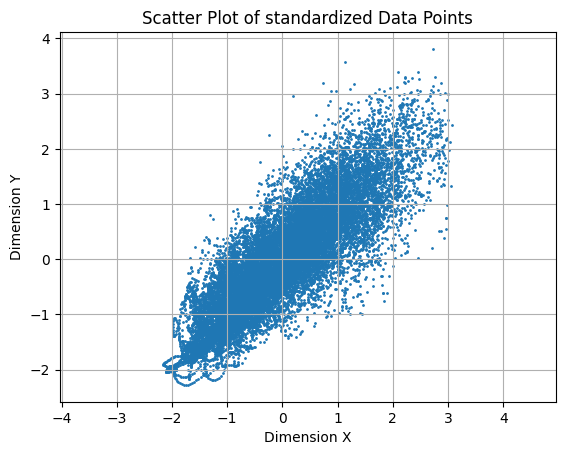

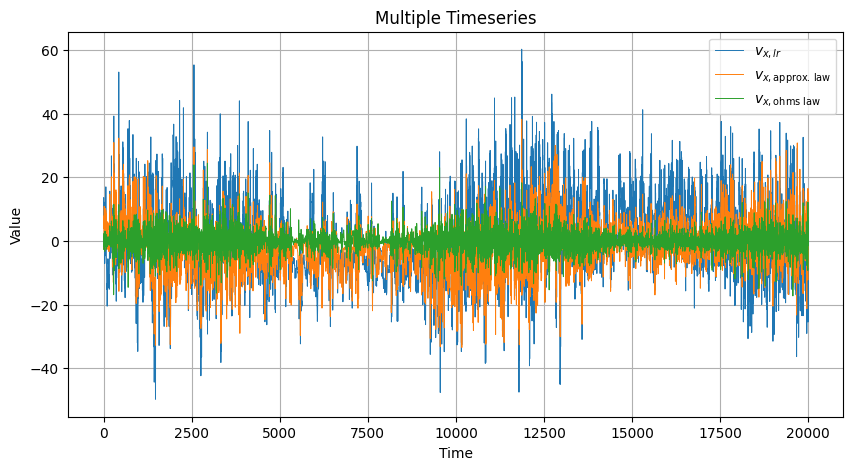

In [53]:
# known j_y + part_phi_y
v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(v_x_center, v_x_ohms_law)}")
print()

# known j_y + approx_part_phi_y
v_x_approx_law = (approx_part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(approx_law) = {mean_squared_error(v_x_center, v_x_approx_law)}")
print()

# pdm
v_x_pdm = approx_part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_approx_law,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x,\\text{approx. law}}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

##### Without Voltage Approximation

mse(ohm's law) = 7.977970680612163

mse(pdm) = 332.1348498632144

mse(c_pdm) = 103.84325393274713

mse(lr) = 76.98128415582886

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005    0.91342626]
 [0.91342626 1.00005   ]]


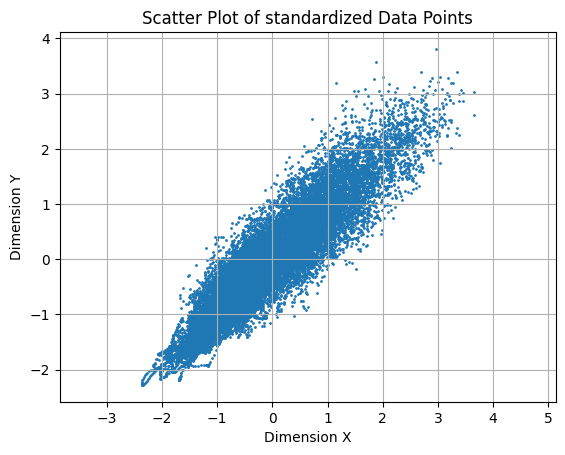

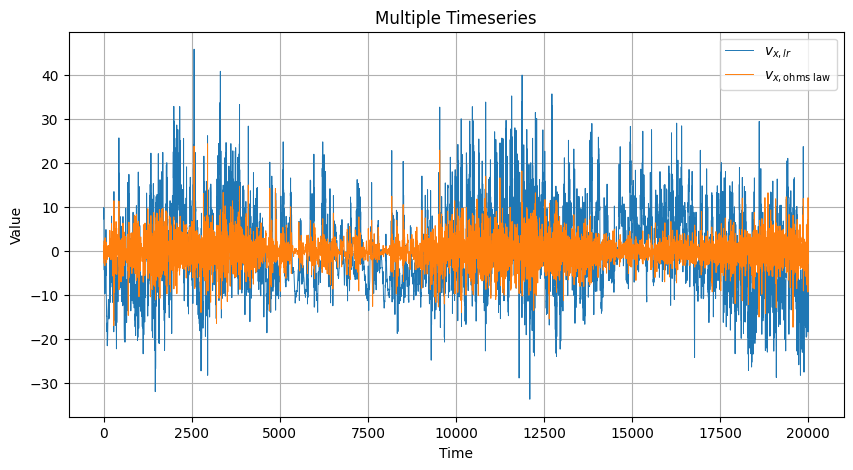

In [54]:
# known j_y + part_phi_y
v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(v_x_center, v_x_ohms_law)}")
print()

# pdm
v_x_pdm = part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

### Comparing $\frac{\Delta{\phi}}{\Delta{y}}$ and $j_y$

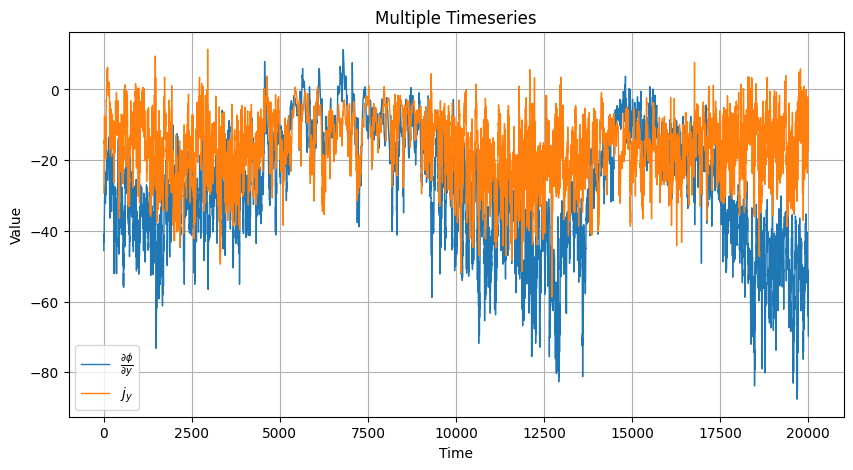

In [35]:
plot_timeseries(
    [
        part_phi_y,
        j_y_center,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{y}}$",
        "$j_{y}$",
        ],
    linewidth=1,
    )

## Ohm's Law in z-coord

### Voltage (Potential Difference) $\Phi$

##### Real Voltage

This one can not be measured directly by the potential probe.

In [36]:
part_phi_z = extract_timeseries(
    data=gradF_data,
    column_labels="dfdz",
    y_coord=y_coord,
    z_coord=z_coord,
    )

##### Approx Voltage with Symmetric Difference Quotient

In [37]:
"""Get indices for symmetric difference quotient points.

z_1_y = (z_1_y, z_1_z)
z_2_y = (z_2_y, z_2_z)
z_1_y = y_coord = z_2_y
z_1_z < z_coord < z_2_z

"""

delta_l = 0.1  # y, z domain = [-1, 1]

print(f"Center: y = {fld_timeseries[0][i_center][0]}, z = {fld_timeseries[0][i_center][1]}")


# Find z_1
z_1_y_desired = y_coord
z_1_z_desired = z_coord - delta_l / 2

# Adjust according to error message. No error will be thrown after correct adjustment.
# z_1_y = z_1_y_desired
# z_1_z = z_1_z_desired
if Ha == 300:
    z_1_y = -0.01842125
    z_1_z = -0.05560156
elif Ha == 1000:
    z_1_y = 0
    z_1_z = -0.03460649

i_z_1 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=z_1_y,
    z_coord=z_1_z,
    )

print(f"z_1 Coordinates: y = {z_1_y}, z = {z_1_z}")
print(f"Difference to center: delta_y^z_1 = {z_1_y - y_coord}, ", end='')
print(f"delta_z^z_1 = {z_1_z - z_coord}, delta_i^z_1 = {i_z_1 - i_center}")


# Find z_2
z_2_y_desired = y_coord
z_2_z_desired = z_coord + delta_l / 2

# Adjust according to error message. No error will be thrown after correct adjustment.
# z_2_y = z_2_y_desired
# z_2_z = z_2_z_desired
if Ha == 300:
    z_2_y = -0.01842125
    z_2_z = 0.01842125
elif Ha == 1000:
    z_2_y = 0
    z_2_z = 0.03460649

i_z_2 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=z_2_y,
    z_coord=z_2_z,
    )

print(f"z_2 Coordinates: y = {z_2_y}, z = {z_2_z}")
print(f"Difference to center: delta_y^z_2 = {z_2_y - y_coord}, ", end='')
print(f"delta_z^z_2 = {z_2_z - z_coord}, delta_i^z_2 = {i_z_2 - i_center}")


# Compare z_1 and z_2
delta_y = z_2_y - z_1_y
delta_z = z_2_z - z_1_z
print(f"Difference between z_1 to z_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_z_2 - i_z_1}")

Center: y = -0.01842125, z = -0.01842125
z_1 Coordinates: y = -0.01842125, z = -0.05560156
Difference to center: delta_y^z_1 = 0.0, delta_z^z_1 = -0.03718031, delta_i^z_1 = -46
z_2 Coordinates: y = -0.01842125, z = 0.01842125
Difference to center: delta_y^z_2 = 0.0, delta_z^z_2 = 0.0368425, delta_i^z_2 = 46
Difference between z_1 to z_2: delta_y = 0.0, delta_z = 0.07402281, delta_i = 92


In [38]:
"""Approximate Voltage with Symmetric Difference Coefficient
"""

phi_z_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=z_1_y,
    z_coord=z_1_z,
    )
phi_z_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=z_2_y,
    z_coord=z_2_z,
    )

delta_phi_z = phi_z_2 - phi_z_1
approx_part_phi_z = delta_phi_z / delta_z

##### Compare Real with Approximate Voltage $\Phi$

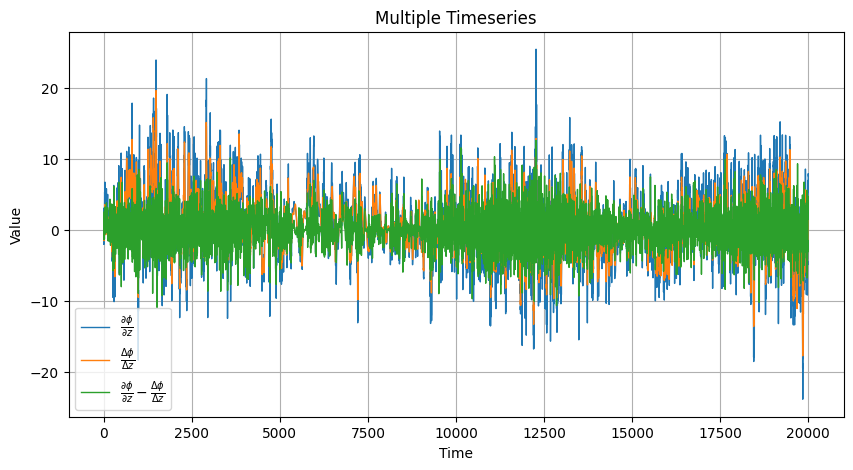

In [39]:
plot_timeseries(
    data_list=[
        part_phi_z,
        approx_part_phi_z,
        part_phi_z - approx_part_phi_z,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
        "$\\frac{\\Delta{\\phi}}{\\Delta{z}}$",
        "$\\frac{\\partial{\\phi}}{\\partial{z}} - \\frac{\\Delta{\\phi}}{\\Delta{z}}$"
        ],
    linewidth=1,
    )

### Error in z

In [40]:
j_z_center = extract_timeseries(
    data=fld_data,
    column_labels='jz',
    y_coord=y_coord,
    z_coord=z_coord,
    )

print(f"mse(part_phi_z) = {mean_squared_error(part_phi_z, j_z_center / sigma)}")

# plot_timeseries(
#     data_list=[
#         # part_phi_z,
#         part_phi_z - j_z_center / sigma_est_round,
#         ],
#     labels=[
#         # "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
#         "err",
#         ],
#     linewidth=0.7,
#     )

mse(part_phi_z) = 5.858277161518981e-07
